# Task 1: character-level GPT from scratch on TinyStories

Poushali Purkayastha, Team 16.

This notebook runs the whole Task 1 pipeline: data preparation, training, generation, and evaluation. The code lives in the modules next to this notebook (`data.py`, `model.py`, `train.py`, `generate.py`, `run.py`) and in the shared `task1_llm/evaluate_task1.py`. The config is read from the `TASK1_CONFIG` environment variable and defaults to `configs/full.yaml`; `configs/smoke.yaml` is the one-minute CPU test.

In [1]:
import os
import runpy
import sys
from pathlib import Path

CONFIG = os.environ.get("TASK1_CONFIG", "configs/full.yaml")
print("config:", CONFIG)
sys.argv = ["run.py", "--config", CONFIG]
runpy.run_path("run.py", run_name="__main__")

config: configs/smoke.yaml


2026-09-20 16:48:39,187 INFO run_id smoke_20260920_164839 member Poushali_Purkayastha task task1_llm


2026-09-20 16:48:39,189 INFO config task1_llm/Poushali_Purkayastha/src/configs/smoke.yaml {"run_name": "smoke", "is_final": false, "seed": 20, "data": {"source": "hf", "hf_dataset": "roneneldan/TinyStories", "block_size": 64, "n_train": 2000, "n_val": 200, "val_story_fraction": 0.1, "char_margin": 1.05}, "model": {"n_layer": 2, "d_model": 64, "n_head": 2, "d_ff": 256, "dropout": 0.1}, "train": {"epochs": 1, "batch_size": 32, "lr": 0.001, "min_lr": 0.0001, "warmup_steps": 10, "schedule": "cosine", "weight_decay": 0.1, "betas": [0.9, 0.95], "grad_clip": 1.0, "amp": true, "log_interval": 10, "eval_batch_size": 64}, "generation": {"prompts": ["Once upon a time"], "max_new_tokens": 60, "temperatures": [1.0], "n_per_prompt": 1}}


2026-09-20 16:48:39,189 INFO hardware {"platform": "Windows-11-10.0.26200-SP0", "python": "3.12.10", "torch": "2.14.0+cpu", "cpu": "Intel64 Family 6 Model 140 Stepping 1, GenuineIntel", "cpu_cores": 8, "ram_gb": 16.9, "cuda_available": false, "cuda_version": null, "gpus": [], "nvidia_smi": "no gpu"}


2026-09-20 16:48:39,189 INFO git {"commit": "80bbe993a703884b96e3406c0a252054f55e0560", "branch": "poushali-branch", "dirty": true}


...

2026-09-20 16:48:44,203 INFO metric Optimizer Steps = 63


2026-09-20 16:48:44,219 INFO metric Device = cpu


2026-09-20 16:48:45,058 INFO manifest reproducibility/manifests/Poushali_Purkayastha_task1_llm_smoke_20260920_164839.json


2026-09-20 16:48:45,059 INFO run finished in 5.9 sec


{'__name__': '__main__',
 '__doc__': None,
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': 'run.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='builtins', loader=<class '_frozen_importlib.BuiltinImporter'>, origin='built-in'),
  '__build_class__': <function __build_class__>,
  '__import__': <function __import__(name, globals=None, locals=None, fromlist=(), level=0)>,
  'abs': <function abs(x, /)>,

,Metric,Value
0,Training Cross-Entropy Loss,3.1863934690990146
1,Validation Cross-Entropy Loss,2.7611412239074706
2,Best Validation Cross-Entropy Loss,2.7611412239074706
3,Perplexity,15.817884399476874
4,Bits-Per-Character,3.983484750925391
5,Generalization Gap,-0.4252522451915439
6,Top-1 Next-Character Accuracy,0.292421875
7,Distinct-1,0.4642857142857143
8,Distinct-2,0.5384615384615384
9,Distinct-3,0.625


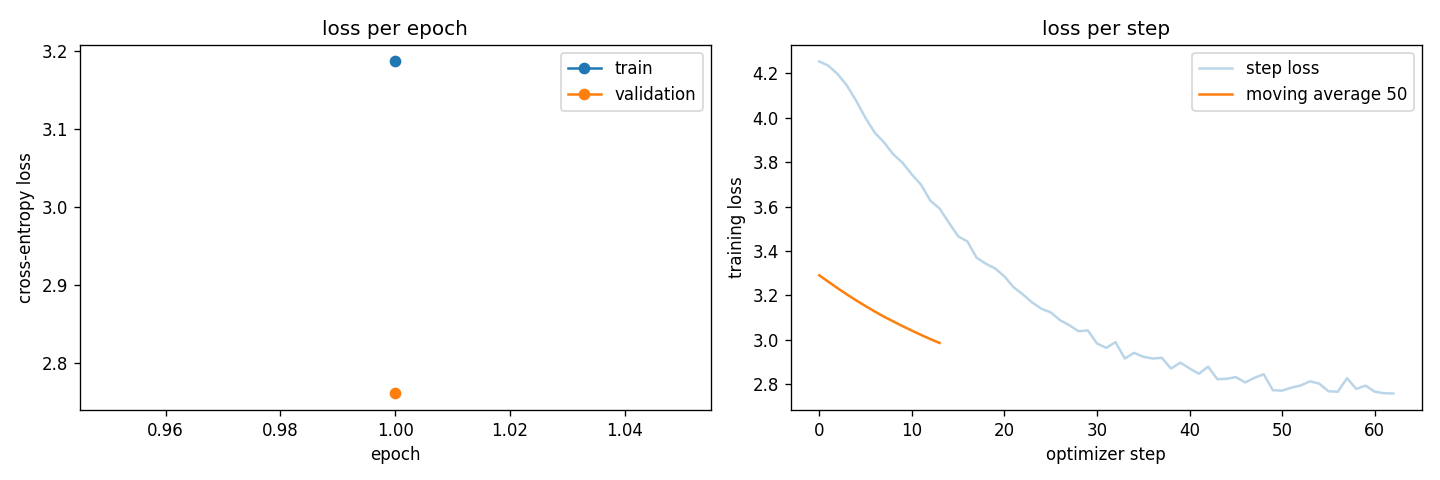

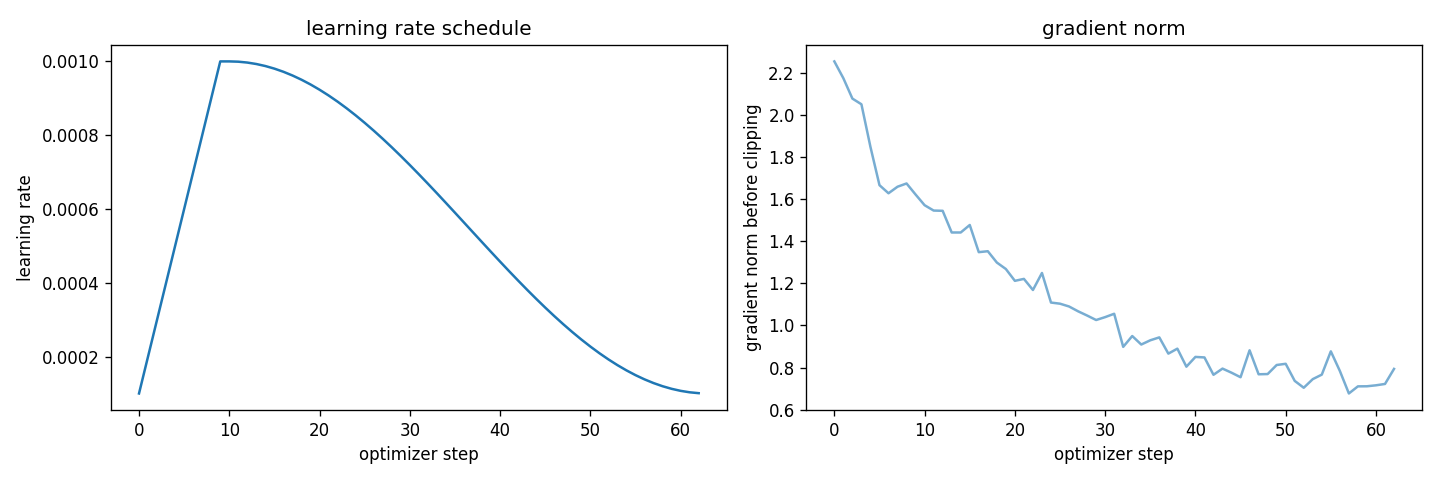

=== sample 1 | prompt: 'Once upon a time' | mode: greedy ===
Once upon a time t t t the the the the the the the the the the t the the the

=== sample 2 | prompt: 'Once upon a time' | mode: temperature_1.0 ===
Once upon a timer uy,  od"!.se iceydy,a ikir j8oed carh, ghwnIes hey mdn e.y



In [2]:
import pandas as pd
import yaml
from IPython.display import Image, display

run_name = yaml.safe_load(Path(CONFIG).read_text(encoding="utf-8"))["run_name"]
out_dir = Path("..") / "outputs" / run_name
display(pd.read_csv(out_dir / "metrics_report.csv"))
display(Image(filename=str(out_dir / "loss_curves.png")))
display(Image(filename=str(out_dir / "training_dynamics.png")))
print((out_dir / "samples.txt").read_text(encoding="utf-8")[:4000])